# Projet Api Immo Lille — Analyse & Modélisation

## 📜 Objectifs
- Charger et explorer le jeu de données des transactions immobilières.
- Nettoyer les données : filtrage, gestion des valeurs manquantes et aberrantes.
- Calculer le `prix_m2` pour les maisons et appartements.
- Modéliser le prix au m² à partir des caractéristiques principales.
- Comparer différents modèles de régression (Arbre, RF, XGBoost, Linéaire).

---

## 📂 1. Chargement des bibliothèques

In [1]:
#import utile pour le projet machine learning 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression


## 📂 2. Chargement et filtrage des données

In [2]:
df = pd.read_csv("../data/lille_2022.csv")

# Ne garder que les logements à 4 pièces
df = df[df["Nombre pieces principales"] == 4]

# Sélection des colonnes utiles
cols = [
    "Surface reelle bati",
    "Nombre pieces principales",
    "Type local",
    "Surface terrain",
    "Nombre de lots",
    "Valeur fonciere",
]
df = df[cols]
df.head()


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
23,92.0,4.0,Appartement,NaN,1,367000.0
26,70.0,4.0,Appartement,NaN,2,170000.0
58,105.0,4.0,Appartement,NaN,2,355300.0
62,120.0,4.0,Appartement,NaN,1,472500.0


## 🏠 3. Séparation Maisons / Appartements et Nettoyage

In [3]:
# Séparer les maisons et appartements
df_maisons = df[df['Type local'].str.lower().str.contains('maison')].copy()
df_apparts = df[df['Type local'].str.lower().str.contains('appartement')].copy()

# Nettoyage des NA :
df_maisons = df_maisons.dropna(subset=['Surface reelle bati', 'Surface terrain', 'Nombre de lots', 'Valeur fonciere'])

# Pour les appartements, on remplace le terrain manquant par 0
df_apparts['Surface terrain'] = df_apparts['Surface terrain'].fillna(0)


## 🔍 4. Vérification des valeurs nulles et zéros

In [4]:
def detect_nan_and_zeros(df: pd.DataFrame) -> pd.DataFrame:
    num_cols = df.select_dtypes(include='number').columns
    results = []
    for col in num_cols:
        n_nan = df[col].isna().sum()
        n_zero = (df[col] == 0).sum()
        results.append({"column": col, "n_nan": n_nan, "n_zero": n_zero})
    return pd.DataFrame(results)

print("Maisons:")
display(detect_nan_and_zeros(df_maisons))

print("\nAppartements:")
display(detect_nan_and_zeros(df_apparts))


Maisons:


,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,0
3,Nombre de lots,0,340
4,Valeur fonciere,0,0



Appartements:


,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,386
3,Nombre de lots,0,49
4,Valeur fonciere,0,0


## 🧮 5. Calcul du prix au m²

In [5]:
df_maisons['prix_m2'] = df_maisons['Valeur fonciere'] / df_maisons['Surface reelle bati']
df_apparts['prix_m2'] = df_apparts['Valeur fonciere'] / df_apparts['Surface reelle bati']


## 📊 6. Analyse exploratoire : distribution et outliers

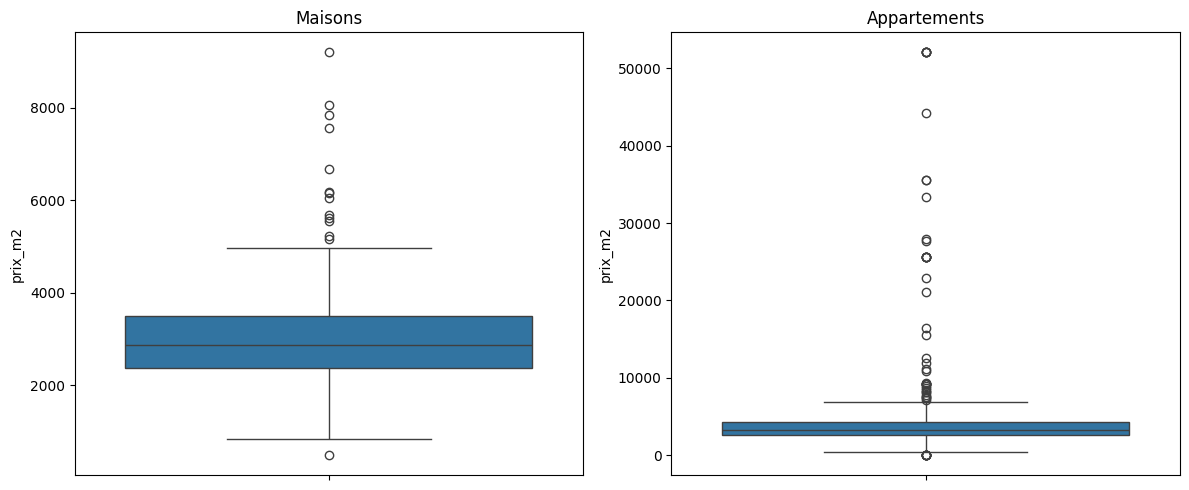

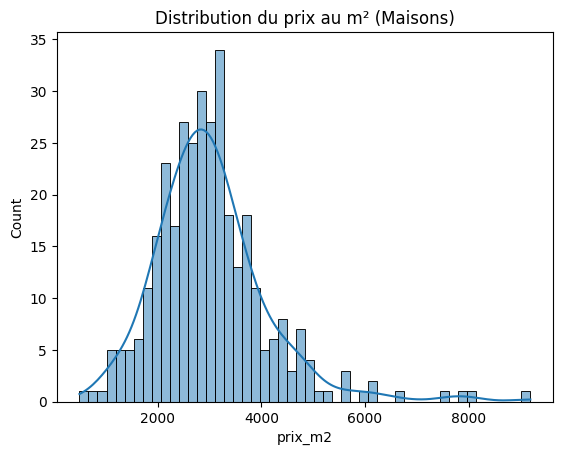

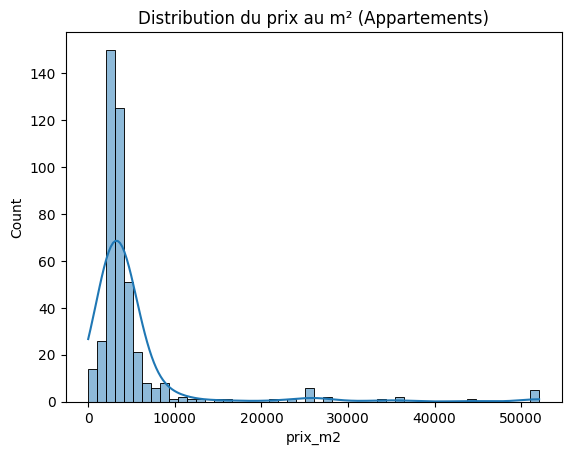

In [6]:
# Boxplots prix/m2
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df_maisons, y='prix_m2', ax=ax[0]).set_title('Maisons')
sns.boxplot(data=df_apparts, y='prix_m2', ax=ax[1]).set_title('Appartements')
plt.tight_layout()
plt.show()

# Distribution
sns.histplot(df_maisons['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² (Maisons)')
plt.show()

sns.histplot(df_apparts['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² (Appartements)')
plt.show()


In [7]:
# # On suppose que ton DataFrame filtré pour les maisons est dans `df_maisons`
# # Et que la variable cible est `prix_m2`

# plt.figure(figsize=(10, 6))

# # 1) Boxplot pour visualiser les valeurs extrêmes
# sns.boxplot(data=df_maisons, y='prix_m2')
# plt.title('Boxplot du prix au m² - Maisons')
# plt.ylabel('Prix au m²')
# plt.grid(axis='y', alpha=0.3)
# plt.show()

# # 2) Nuage de points entre surface et prix_m2 pour voir la tendance
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_maisons, x='Surface reelle bati', y='prix_m2')
# plt.title('Prix au m² en fonction de la surface (Maisons)')
# plt.xlabel('Surface réelle bâtie (m²)')
# plt.ylabel('Prix au m²')
# plt.grid(alpha=0.3)
# plt.show()

# # 3) Distribution des prix au m²
# plt.figure(figsize=(10, 6))
# sns.histplot(df_maisons['prix_m2'], bins=50, kde=True)
# plt.title('Distribution du prix au m² - Maisons')
# plt.xlabel('Prix au m²')
# plt.ylabel('Count')
# plt.grid(axis='y', alpha=0.3)
# plt.show()

In [8]:
# # On suppose que ton DataFrame filtré pour les appartements est dans `df_appartements`

# plt.figure(figsize=(10, 6))
# sns.boxplot(data=df_apparts, y='prix_m2')
# plt.title('Boxplot du prix au m² - Appartements')
# plt.ylabel('Prix au m²')
# plt.grid(axis='y', alpha=0.3)
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_apparts, x='Surface reelle bati', y='prix_m2')
# plt.title('Prix au m² en fonction de la surface (Appartements)')
# plt.xlabel('Surface réelle bâtie (m²)')
# plt.ylabel('Prix au m²')
# plt.grid(alpha=0.3)
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.histplot(df_apparts['prix_m2'], bins=50, kde=True)
# plt.title('Distribution du prix au m² - Appartements')
# plt.xlabel('Prix au m²')
# plt.ylabel('Count')
# plt.grid(axis='y', alpha=0.3)
# plt.show()


## 🔍 7. Détection et suppression des valeurs aberrantes

In [9]:
def detect_outliers(df, column):
    Q1, Q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return lb, ub

# Nettoyage pour les maisons
for col in ['prix_m2', 'Surface reelle bati', 'Surface terrain']:
    lb, ub = detect_outliers(df_maisons, col)
    df_maisons = df_maisons[(df_maisons[col] >= lb) & (df_maisons[col] <= ub)]

# Nettoyage pour les appartements
for col in ['prix_m2', 'Surface reelle bati']:
    lb, ub = detect_outliers(df_apparts, col)
    df_apparts = df_apparts[(df_apparts[col] >= lb) & (df_apparts[col] <= ub)]

## 🧮 8. Sélection des features et de la cible

In [10]:
features_maison = ["Surface reelle bati", "Surface terrain"]
features_apparts = ["Surface reelle bati", "Nombre de lots"]

target = "prix_m2"

X_maisons, y_maisons = df_maisons[features_maison], df_maisons[target]
X_apparts, y_apparts = df_apparts[features_apparts], df_apparts[target]

## 🤖 9. Fonction d’entraînement et d’évaluation des modèles


In [11]:
# ========================
# Fonction d’entraînement
# ========================
def run_all_models(df, features, target, title="Comparaison des modèles"):
    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grids = {
        "Decision Tree": {"model__max_depth": [3, 5, None], "model__min_samples_split": [2, 10]},
        "Random Forest": {"model__n_estimators": [50, 100], "model__max_depth": [3, None]},
        "XGBoost": {"model__n_estimators": [50, 100], "model__learning_rate": [0.01, 0.1]},
    }
    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    }

    results = {}
    best_pipelines = {}

    # Boucle sur les modèles
    for name, model in models.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
        grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring="r2", n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        rmse = root_mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
        best_pipelines[name] = best_model

    # Modèle linéaire + SelectKBest
    pipe_lin = Pipeline([("scaler", StandardScaler()), ("select", SelectKBest(score_func=f_regression)), ("model", LinearRegression())])
    param_grid_lin = {"select__k": list(range(1, len(features) + 1))}
    grid_lin = GridSearchCV(pipe_lin, param_grid_lin, cv=5, scoring="r2", n_jobs=-1)
    grid_lin.fit(X_train, y_train)

    best_model_lin = grid_lin.best_estimator_
    y_pred_lin = best_model_lin.predict(X_test)

    rmse_lin = root_mean_squared_error(y_test, y_pred_lin)
    mae_lin = mean_absolute_error(y_test, y_pred_lin)
    r2_lin = r2_score(y_test, y_pred_lin)

    results["Linear + SelectKBest"] = {"RMSE": rmse_lin, "MAE": mae_lin, "R2": r2_lin}
    best_pipelines["Linear + SelectKBest"] = best_model_lin

    # Comparaison graphique
    results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    sns.barplot(data=results_df, x="Model", y="RMSE", ax=ax[0], palette="Blues_d").set_title("Comparaison des RMSE")
    sns.barplot(data=results_df, x="Model", y="R2", ax=ax[1], palette="Greens_d").set_title("Comparaison des R2")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    return results_df, best_pipelines

In [12]:
# ========================
# Fonction d'export
# ========================
def save_models(best_pipelines, prefix):
    for name, model in best_pipelines.items():
        filename = f"{prefix}_{name.replace(' ', '_').replace('+', 'plus')}.pkl"
        joblib.dump(model, filename)
        print(f"✅ Modèle {name} sauvegardé dans {filename}")

### Modèles pour maisons ###


/tmp/ipykernel_48859/3050138371.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", ax=ax[0], palette="Blues_d").set_title("Comparaison des RMSE")
/tmp/ipykernel_48859/3050138371.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", ax=ax[1], palette="Greens_d").set_title("Comparaison des R2")


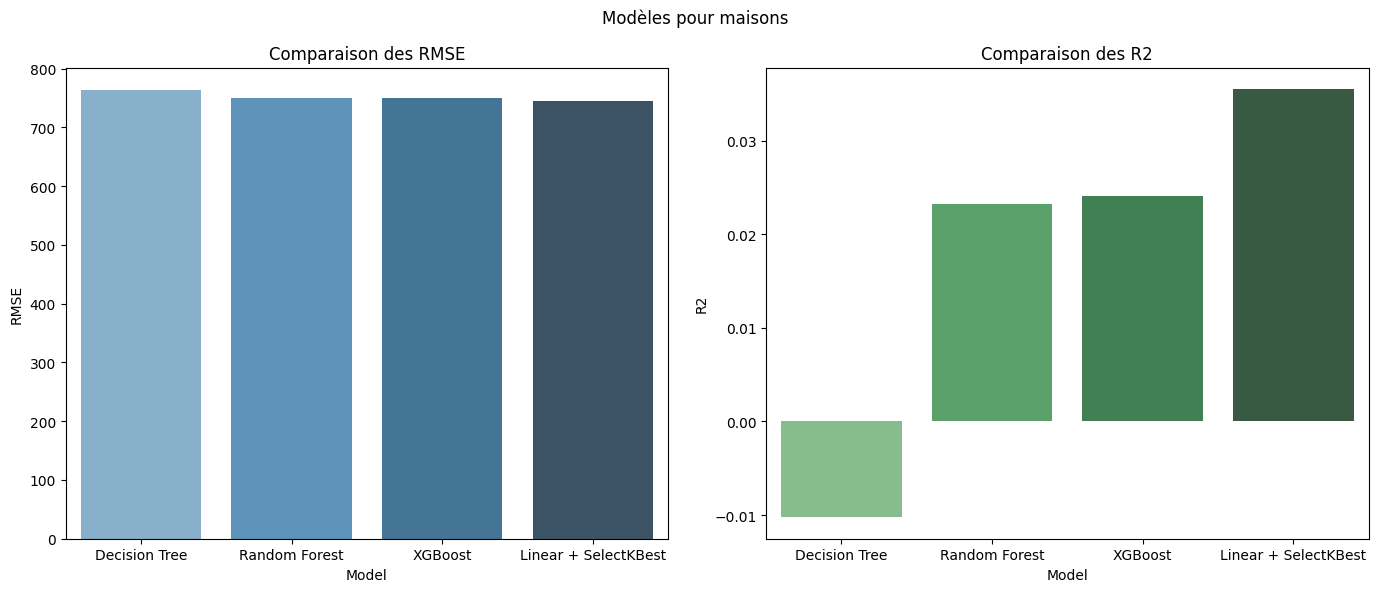

✅ Modèle Decision Tree sauvegardé dans maisons_Decision_Tree.pkl
✅ Modèle Random Forest sauvegardé dans maisons_Random_Forest.pkl
✅ Modèle XGBoost sauvegardé dans maisons_XGBoost.pkl
✅ Modèle Linear + SelectKBest sauvegardé dans maisons_Linear_plus_SelectKBest.pkl

### Modèles pour appartements ###


/tmp/ipykernel_48859/3050138371.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", ax=ax[0], palette="Blues_d").set_title("Comparaison des RMSE")
/tmp/ipykernel_48859/3050138371.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", ax=ax[1], palette="Greens_d").set_title("Comparaison des R2")


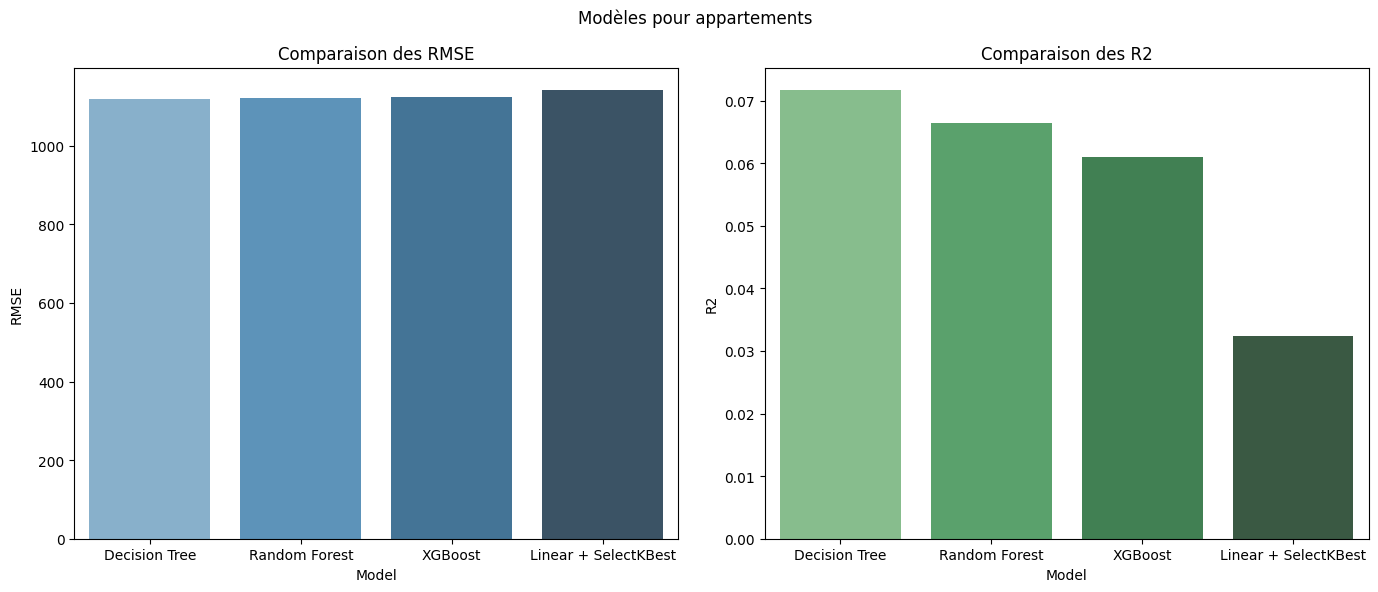

✅ Modèle Decision Tree sauvegardé dans apparts_Decision_Tree.pkl
✅ Modèle Random Forest sauvegardé dans apparts_Random_Forest.pkl
✅ Modèle XGBoost sauvegardé dans apparts_XGBoost.pkl
✅ Modèle Linear + SelectKBest sauvegardé dans apparts_Linear_plus_SelectKBest.pkl


In [13]:
# Définition des features et target
features_maison = ["Surface reelle bati", "Surface terrain"]
features_apparts = ["Surface reelle bati", "Nombre de lots"]
target = "prix_m2"

# Lancement de l'entraînement et sauvegarde pour les maisons
print("### Modèles pour maisons ###")
results_maison, best_models_maison = run_all_models(df_maisons, features_maison, target, title="Modèles pour maisons")
save_models(best_models_maison, prefix="maisons")

# Lancement de l'entraînement et sauvegarde pour les appartements
print("\n### Modèles pour appartements ###")
results_apparts, best_models_apparts = run_all_models(df_apparts, features_apparts, target, title="Modèles pour appartements")
save_models(best_models_apparts, prefix="apparts")
